# Function Design for Reusable Visualizations

## Goal

In this notebook, we move from **one-off analysis** to **reusable functions**.

We want to:

- avoid repeating code  
- create consistent, clean visualizations  
- easily reuse plots across multiple datasets  

---

## Why functions?

So far, we have repeatedly:

- plotted values over time  
- compared groups (e.g. continents)  
- created maps  

Instead of rewriting code, we will:

- write functions once  
- reuse them by changing inputs (dataframe, column, year, etc.)

---

## Focus

At this stage, we also improve **visual quality**.

Our functions should produce plots that are:

- clear  
- consistent  
- easy to interpret  

---

## Workflow

1. create functions in this notebook  
2. test and refine them  
3. later move them to `functions.py`  

---

## What we will build

Functions for:

- data inspection  
- time series plots  
- grouped plots  
- growth rate calculation  
- world map visualizations (`.plot` and `.explore`)  

---

## Key idea

> Build once, reuse everywhere.

We start by loading the population data and the cleaning functions used previously from `functions.py`.

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from functions import remove_aggregate_rows, add_continent_column, load_clean_data
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

gdp_df = load_clean_data('./data/gdp.csv')
gdp_df.head()

,country,country_code,year,gdp,continent
0,Afghanistan,AFG,2000,6206547590,Asia
1,Afghanistan,AFG,2001,5621147630,Asia
2,Afghanistan,AFG,2002,7228795918,Asia
3,Afghanistan,AFG,2003,7867263256,Asia
4,Afghanistan,AFG,2004,7978515641,Asia


## Reusable Line Plot Function

We want a function that can handle two common cases:

- a **global line plot** with aggregation over all countries
- a **grouped line plot** using a `hue` column such as `continent`

It should also support a `relative=True` mode, where we plot **year-over-year percentage growth** instead of absolute values.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def plot_time_series(
    df,
    value_col,
    agg_func="sum",
    year_col="year",
    hue_col=None,
    relative=False,
    title=None,
    ylabel=None,
    ax=None,
    **kwargs
):
    """
    Plot a time series either globally or grouped by a hue column.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    value_col : str
        Column containing the value to aggregate and plot.
    agg_func : str or function, default="sum"
        Aggregation function to apply (e.g. "sum", "mean", or a custom function).
    year_col : str, default="year"
        Column containing the year/time variable.
    hue_col : str or None, default=None
        Optional grouping column (e.g. continent). If None, plot the global aggregate.
    relative : bool, default=False
        If True, plot year-over-year percentage growth instead of absolute values.
    title : str or None, default=None
        Plot title.
    ylabel : str or None, default=None
        Label for the y-axis.
    ax : matplotlib.axes.Axes or None, default=None
        Optional axes to plot on. If None, a new figure and axes will be created.
    **kwargs
        Additional keyword arguments to pass to seaborn.lineplot.

    Returns
    -------
    pd.DataFrame
        Aggregated dataframe used for plotting.
    """
    # Your code goes here
    if hue_col is not None:
        df_group = df.groupby([year_col, hue_col])[value_col].agg(agg_func).reset_index()
    else:
        df_group = df.groupby([year_col])[value_col].agg(agg_func).reset_index()



    if relative and hue_col is not None:
        df_group['growth_rate'] = (df_group.groupby([hue_col])[value_col].pct_change() * 100)
    elif relative and hue_col is None:
        df_group['growth_rate'] = (df_group[value_col].pct_change() * 100)


    if relative:
        value_col = 'growth_rate'

    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))


    if hue_col is not None:
        sns.lineplot(x=year_col, y=value_col, hue=hue_col, data=df_group, ax=ax, **kwargs)
    else:
        sns.lineplot(x=year_col, y=value_col, data=df_group, ax=ax, **kwargs)
    
    ax.set_title(title)
    ax.set_xlabel(year_col.capitalize())
    ax.set_ylabel(ylabel)
    ax.grid(axis='both', linestyle='--', alpha=0.5)

    return df_group, ax

## Example 1 — Global GDP over time

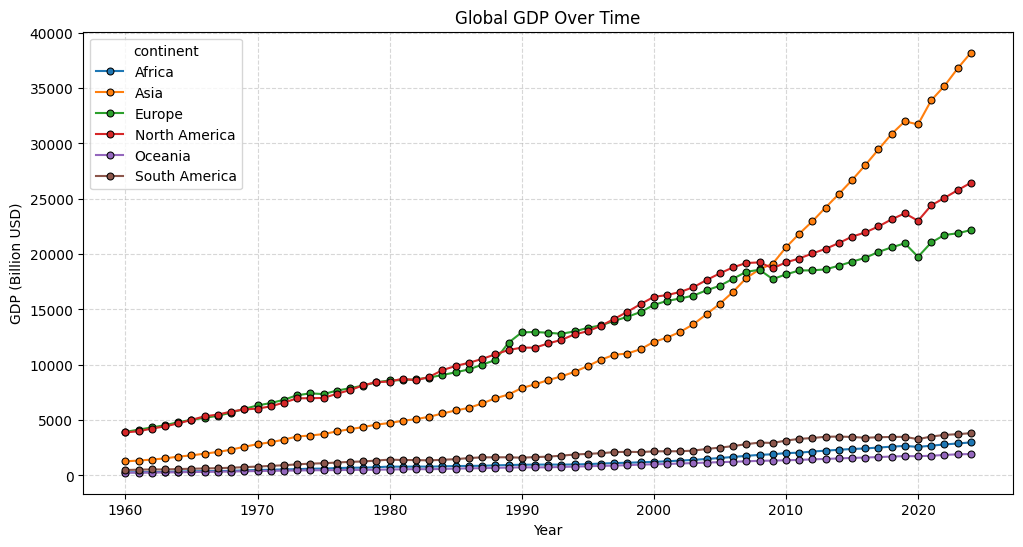

In [24]:
gdp_df['gdp_billion'] = gdp_df['gdp'] / 1e9

fig, ax = plt.subplots(figsize=(12, 6))
df_plot, _ = plot_time_series(
    df=gdp_df,
    value_col="gdp_billion",
    hue_col="continent",
    title="Global GDP Over Time",
    ylabel="GDP (Billion USD)",
    relative=False,
    ax=ax,
    marker='o',
    markersize=5,
    markeredgecolor='black',

)

## Example 2 — GDP growth over time

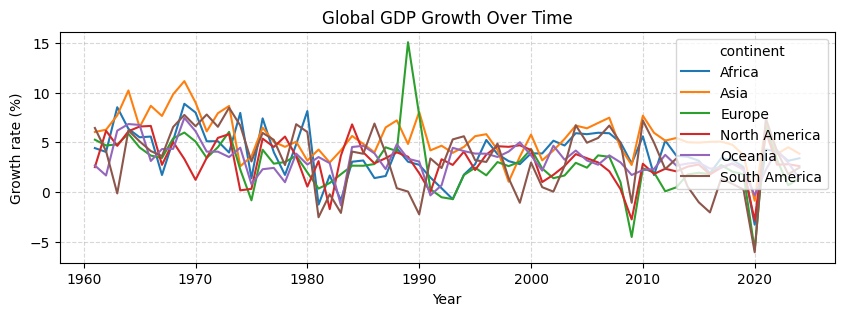

In [25]:
df, _ = plot_time_series(
    df=gdp_df,
    value_col="gdp",
    hue_col='continent',
    relative=True,
    title="Global GDP Growth Over Time",
    ylabel="Growth rate (%)"
)

## Example 3 — GDP by continent

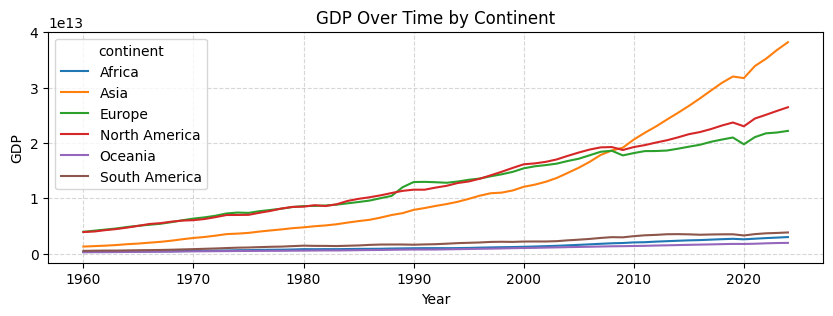

In [26]:
df_plot, _ = plot_time_series(
    df=gdp_df,
    value_col="gdp",
    hue_col="continent",
    title="GDP Over Time by Continent",
    ylabel="GDP"
)

# Reusable World Map Visualization

## Goal

We now design a reusable function to visualize data on a **world map**.

The function should:

- take any dataset with `country_code`, `year`, and a value column  
- merge it with geographic data  
- allow selecting a specific year  
- support both:
  - static maps (`.plot`)
  - interactive maps (`.explore`)  

---

## Step 1 — Load World Map (once)

We load the map once and reuse it.

In [ ]:
import geopandas as gpd

world_gdf = gpd.read_file(
    "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_0_countries.geojson"
)[['admin', 'adm0_a3', 'geometry']]

## Step 2 — Design the Function

# Example Usage

## 1. Static map (default)

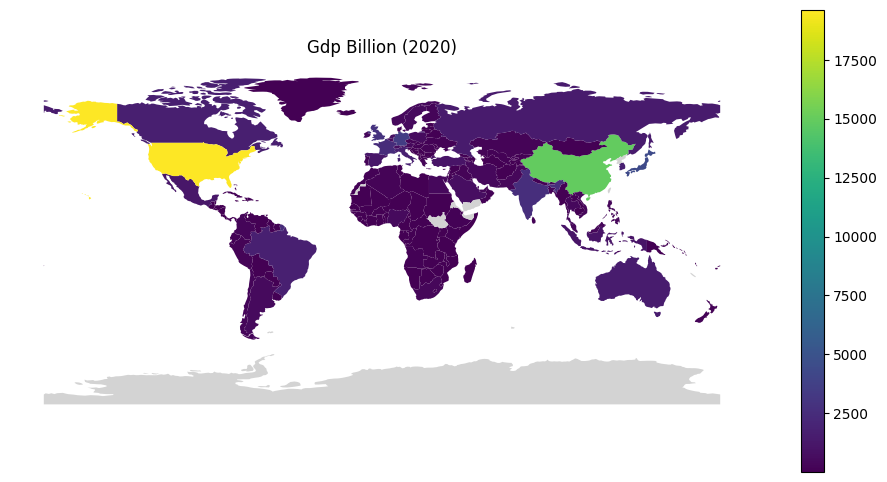

In [31]:
from functions import plot_world_map

plot_world_map(
    df=gdp_df,
    value_col="gdp_billion",
    year=2020
)

## 2. Log-scaled map

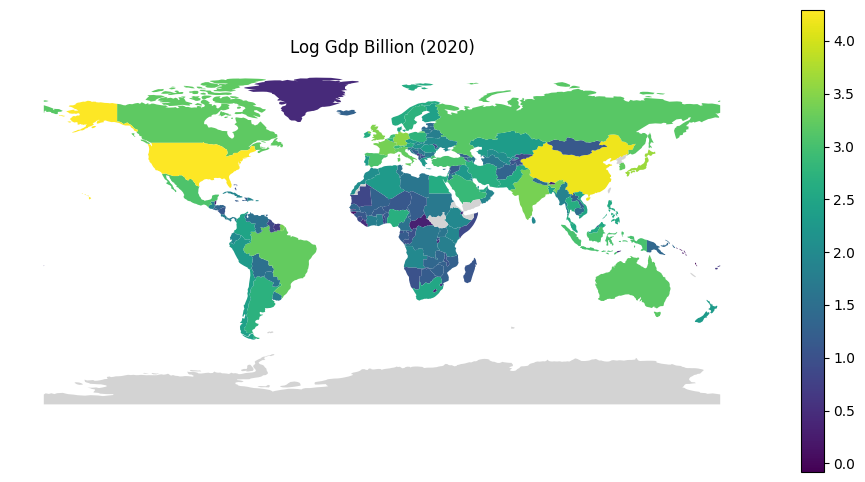

In [32]:
plot_world_map(
    df=gdp_df,
    value_col="gdp_billion",
    year=2020,
    log_scale=True
)

## 3. Interactive map

In [33]:
plot_world_map(
    df=gdp_df,
    value_col="gdp_billion",
    year=2020,
    log_scale=True,
    interactive=True
)

Now let's look at life expectancy.

In [27]:
life_exp_df = load_clean_data('./data/life-expectancy.csv')
life_exp_df.head()

,country,country_code,year,life_expectancy,continent
0,Afghanistan,AFG,1950,28.1563,Asia
1,Afghanistan,AFG,1951,28.5836,Asia
2,Afghanistan,AFG,1952,29.0138,Asia
3,Afghanistan,AFG,1953,29.4521,Asia
4,Afghanistan,AFG,1954,29.6975,Asia


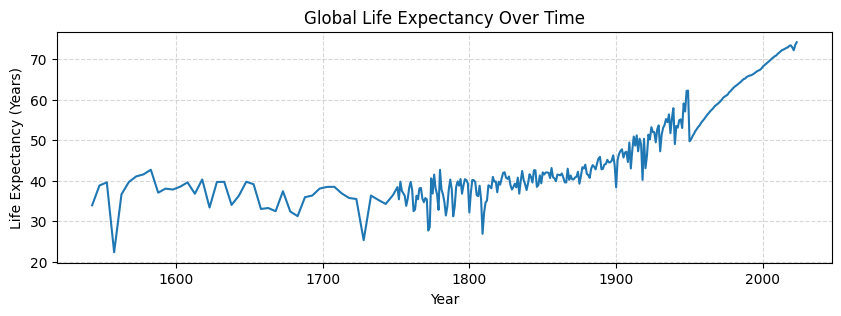

In [28]:
df_plot, _ = plot_time_series(
    df=life_exp_df,
    value_col="life_expectancy",
    agg_func="mean",
    title="Global Life Expectancy Over Time",
    ylabel="Life Expectancy (Years)"
)

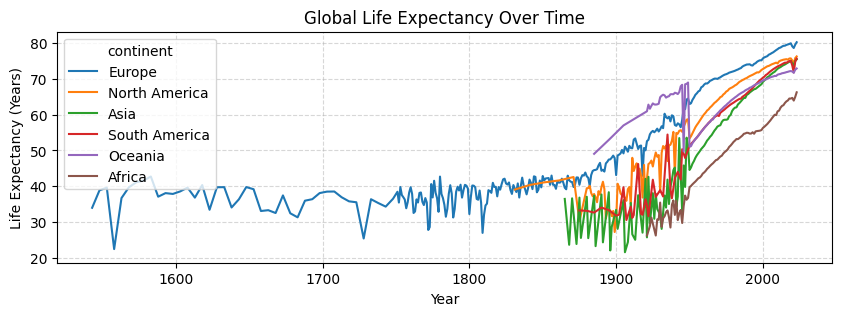

In [29]:
df_plot, _ = plot_time_series(
    df=life_exp_df,
    value_col="life_expectancy",
    agg_func="mean",
    hue_col="continent",
    title="Global Life Expectancy Over Time",
    ylabel="Life Expectancy (Years)"
)

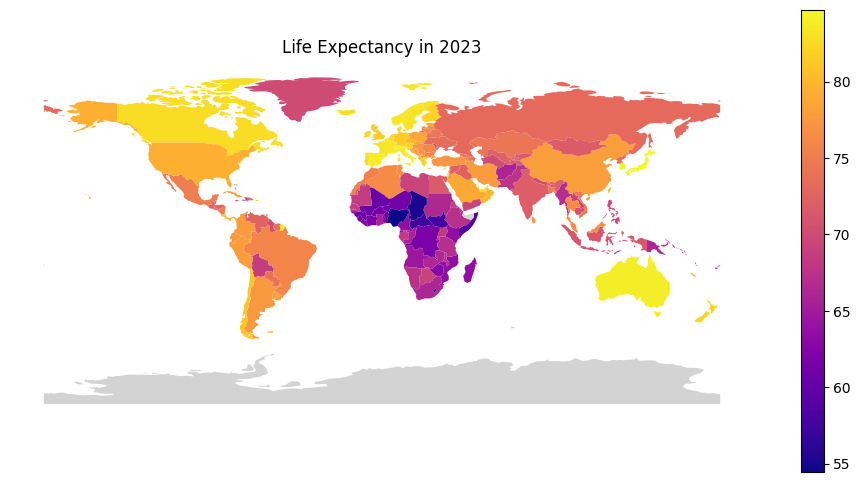

In [35]:
from functions import plot_world_map

plot_world_map(
    df=life_exp_df,
    value_col="life_expectancy",
    year=2023,
    cmap="plasma",
    title="Life Expectancy in 2023"
)

In [1]:
from functions import load_clean_data

population_df = load_clean_data('./data/population.csv')
gdp_df = load_clean_data('./data/gdp.csv')
life_exp_df = load_clean_data('./data/life-expectancy.csv')

In [2]:
df_merged = population_df.merge(gdp_df, on=['country', 'year'], how='inner').merge(life_exp_df, on=['country', 'year'], how='inner')
df_merged = df_merged[['country', 'year', 'population', 'gdp', 'life_expectancy', 'continent']]

In [3]:
df_merged['gdp_per_capita'] = df_merged['gdp'] / df_merged['population']

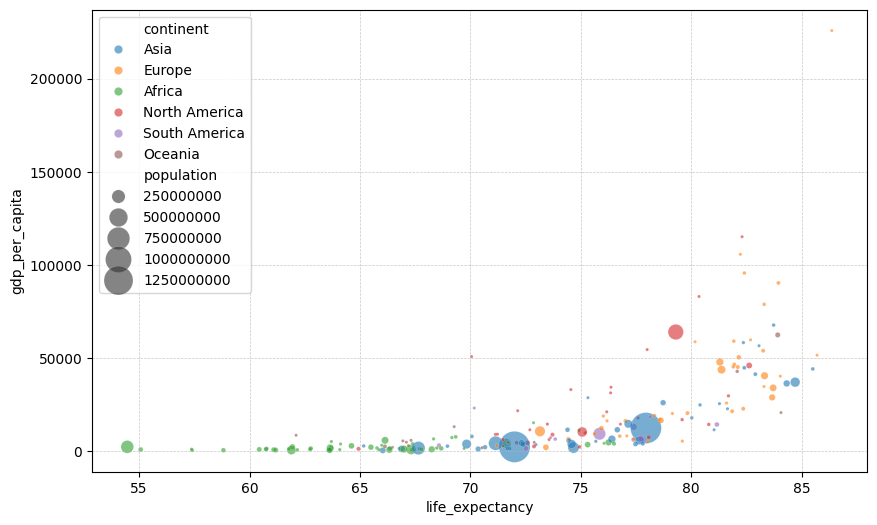

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns 
year = 2023
fix, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_merged[df_merged['year'] == year], y='gdp_per_capita', x='life_expectancy',  hue='continent', alpha=0.6, sizes=(5, 500), size='population')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

In [11]:
df_merged[df_merged['year'] == year].sort_values('life_expectancy', ascending=True).head(10)

,country,year,population,gdp,life_expectancy,continent,gdp_per_capita
7454,Nigeria,2023,227882949,519782610025,54.4623,Africa,2280.919272
2000,Chad,2023,19319075,16553201687,55.0692,Africa,856.832001
5722,Lesotho,2023,2311476,2252257815,57.3749,Africa,974.380792
1936,Central African Republic,2023,5152415,2047921417,57.4077,Africa,397.468258
9287,Somalia,2023,18358622,8531635197,58.8158,Africa,464.720892
6294,Mali,2023,23769130,21210639746,60.4394,Africa,892.360795
4194,Guinea,2023,14405469,14648645956,60.7405,Africa,1016.880877
1067,Benin,2023,14111035,17831007125,60.7738,Africa,1263.621494
1569,Burkina Faso,2023,23025777,17163536264,61.0920,Africa,745.405302
7390,Niger,2023,26159863,14586026438,61.1833,Africa,557.572738
